In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt 

In [2]:
image = cv2.imread(
  "../Data/Dog.jpg",cv2.IMREAD_GRAYSCALE
)

In [4]:
# Generate Gaussian Noise
mean = 0
sigma = 75

noise = np.random.normal(
  mean,
  sigma,
  image.shape
)

noisy = image.astype(np.float32) + noise

In [5]:
noisy = np.clip(
  noisy,
  0,
  255
).astype(np.uint8)

In [7]:
cv2_filtered = cv2.GaussianBlur(noisy, (7,7) , 2)

In [ ]:
def gaussian_filter(image, kernel_size=7, sigma=2):

    # 1. Find kernel center
    k = kernel_size // 2

    # 2. Create coordinate grid
    x, y = np.mgrid[-k:k+1, -k:k+1]

    # 3. Create Gaussian kernel
    kernel = (
        1 / (2 * np.pi * sigma**2)
    ) * np.exp(
        -(x**2 + y**2) / (2 * sigma**2)
    )

    # 4. Normalize kernel
    kernel /= np.sum(kernel)

    # 5. Pad image
    padded = np.pad(
        image,
        ((k, k), (k, k)),
        mode='edge'
    )

    # 6. Create output image
    out_h, out_w = image.shape

    filtered = np.zeros(
        (out_h, out_w),
        dtype=np.float32
    )

    # 7. Convolution
    for i in range(out_h):
        for j in range(out_w):

            region = padded[
                i:i + kernel_size,
                j:j + kernel_size
            ]

            filtered[i, j] = np.sum(
                region * kernel
            )

    # 8. Convert to valid image range
    return np.clip(
        filtered,
        0,
        255
    ).astype(np.uint8)

NameError: name 'my_filtered' is not defined

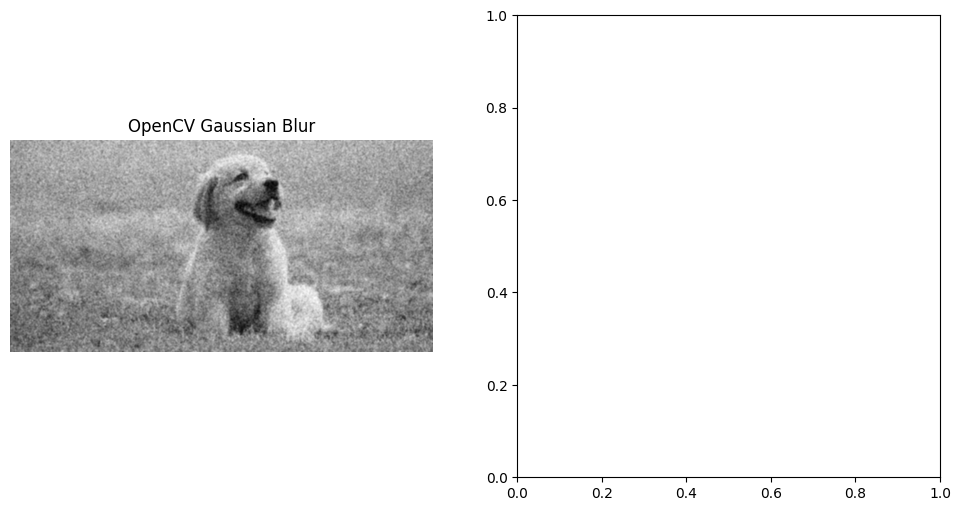

In [15]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2_filtered, cmap="gray")
plt.title("OpenCV Gaussian Blur")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(my_filtered, cmap="gray")
plt.title("Our Gaussian Filter")
plt.axis("off")

plt.tight_layout()
plt.show()